# NutriMap NutriHog of Ozark
**NAFSI Student Data Challenge 2026 | Track 2: NourishNet**  
University of Arkansas, Fayetteville

**Run: Kernel → Restart & Run All**

In [1]:
# CELL 1 — Auto-install dependencies + Environment Setup
import subprocess, sys, warnings

# ── Install ALL packages in one pip call (faster, avoids repeated subprocess overhead)
_pkgs = ["ipywidgets", "xgboost", "shap", "folium", "requests",
         "matplotlib", "seaborn", "scikit-learn", "pandas", "numpy"]
_missing = []
for pkg in _pkgs:
    _import_name = {"scikit-learn": "sklearn"}.get(pkg, pkg)
    try:
        __import__(_import_name)
    except ImportError:
        _missing.append(pkg)

if _missing:
    print(f"Installing: {_missing}")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + _missing, check=True)
    print("All packages installed.")
else:
    print("All packages already present.")

# ── Suppress all warnings BEFORE imports that trigger them
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import os, shutil, io, zipfile
import pandas as pd
import numpy as np
import requests
np.random.seed(42)

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, classification_report, silhouette_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.cluster import DBSCAN
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.neighbors import NearestNeighbors

import xgboost as xgb
print(f"XGBoost {xgb.__version__}")
import shap
print(f"SHAP {shap.__version__}")

import folium
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 300})
os.makedirs("figures", exist_ok=True)

PERSIST_DIR = os.path.expanduser("~/work/_User-Persistent-Storage_CephBlock_/NutriHog-outputs")
CACHE_PATH  = os.path.expanduser("~/work/NutriHog-of-Ozark/nutrihog_county_data.csv")
os.makedirs(PERSIST_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)
print("Environment ready.")


Installing: ['matplotlib', 'seaborn']
All packages installed.
XGBoost 3.2.0
SHAP 0.51.0
Environment ready.


In [2]:
# CELL 2 Data Acquisition

def fetch_census_acs():
    vars_list = ["B17001_002E","B17001_001E","B19013_001E",
                 "B23025_005E","B23025_003E","B01001_001E",
                 "B09001_001E","B25044_003E","B25044_010E"]
    url = ("https://api.census.gov/data/2021/acs/acs5"
           "?get=NAME," + ",".join(vars_list) + "&for=county:*")
    r = requests.get(url, timeout=90)
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    df["fips"] = df["state"] + df["county"]
    for c in vars_list:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["poverty_rate"]      = (df["B17001_002E"]/df["B17001_001E"]*100).clip(0,100)
    df["median_income"]     = df["B19013_001E"].clip(lower=0)
    df["unemployment_rate"] = (df["B23025_005E"]/df["B23025_003E"]*100).clip(0,100)
    df["population"]        = df["B01001_001E"]
    df["pct_under18"]       = (df["B09001_001E"]/df["B01001_001E"]*100).clip(0,100)
    df["pct_no_vehicle"]    = ((df["B25044_003E"]+df["B25044_010E"])/df["B01001_001E"]*100).clip(0,100)
    df[["county","state_name"]] = df["NAME"].str.split(", ", n=1, expand=True)
    keep = ["fips","county","state_name","poverty_rate","median_income",
            "unemployment_rate","population","pct_under18","pct_no_vehicle"]
    return df[keep].copy()

def fetch_cdc_places():
    url = ("https://data.cdc.gov/resource/swc5-untb.csv"
           "?$limit=4000&$select=locationid,obesity_crudeprev,diabetes_crudeprev")
    df = pd.read_csv(url, dtype={"locationid":str})
    df = df.rename(columns={"locationid":"fips","obesity_crudeprev":"obesity_rate",
                             "diabetes_crudeprev":"diabetes_rate"})
    df["fips"] = df["fips"].str.zfill(5)
    return df[["fips","obesity_rate","diabetes_rate"]].copy()

def build_synthetic(n=3221):
    """Spatially-clustered synthetic data — mirrors real US poverty geography."""
    rng = np.random.default_rng(42)
    cluster_centers = [
        (32,-90,0.85),(37,-83,0.75),(35,-97,0.65),
        (44,-100,0.50),(40,-95,0.40),(38,-120,0.30),(42,-75,0.35)
    ]
    lats,lons,latent = [],[],[]
    per = n // len(cluster_centers)
    for lat_c,lon_c,risk_c in cluster_centers:
        lats.extend(rng.normal(lat_c,3.5,per))
        lons.extend(rng.normal(lon_c,5.0,per))
        latent.extend(rng.normal(risk_c,0.18,per))
    rem = n - len(lats)
    lats.extend(rng.uniform(25,49,rem))
    lons.extend(rng.uniform(-124,-68,rem))
    latent.extend(rng.normal(0.45,0.2,rem))
    lats   = np.clip(lats[:n],24,50)
    lons   = np.clip(lons[:n],-125,-66)
    latent = np.array(latent[:n])
    states = ["AL","AR","AZ","CA","CO","FL","GA","IA","ID","IL","IN","KS",
              "KY","LA","MA","MD","ME","MI","MN","MO","MS","MT","NC","ND",
              "NE","NJ","NM","NV","NY","OH","OK","OR","PA","SC","SD","TN",
              "TX","UT","VA","VT","WA","WI","WV","WY"]
    pop = np.clip(rng.lognormal(10,1.5,n),500,5_000_000).astype(int)
    return pd.DataFrame({
        "fips":               [f"SY{i:04d}" for i in range(1,n+1)],  # SY prefix = synthetic
        "county":             [f"County_{i}" for i in range(1,n+1)],
        "state":              [states[i%len(states)] for i in range(n)],
        "lat": lats, "lon": lons, "population": pop,
        "poverty_rate":          np.clip(15+12*latent+rng.normal(0,2,n),2,55),
        "unemployment_rate":     np.clip(5+5*latent+rng.normal(0,1.5,n),1,25),
        "median_income":         np.clip(55000-20000*latent+rng.normal(0,4000,n),20000,120000),
        "snap_participation_rate": np.clip(12+10*latent+rng.normal(0,2,n),1,45),
        "food_insecurity_rate":  np.clip(11+9*latent+rng.normal(0,1.5,n),2,35),
        "obesity_rate":          np.clip(32+6*latent+rng.normal(0,3,n),15,55),
        "diabetes_rate":         np.clip(10+4*latent+rng.normal(0,2,n),3,25),
        "pct_under18":           np.clip(22+3*latent+rng.normal(0,3,n),12,38),
        "pct_no_vehicle":        np.clip(5+6*latent+rng.normal(0,2,n),0,30),
        "rural_urban_code":      np.clip((9*latent+rng.normal(0,1,n)).astype(int),1,9),
    })

if os.path.exists(CACHE_PATH):
    print(f"Loading cache: {CACHE_PATH}")
    df = pd.read_csv(CACHE_PATH, dtype={"fips":str})
else:
    print("Downloading from public APIs...")
    acs,cdc = None,None
    try: acs=fetch_census_acs(); print(f"  ACS: {len(acs):,} counties")
    except Exception as e: print(f"  ACS failed: {e}")
    try: cdc=fetch_cdc_places(); print(f"  CDC: {len(cdc):,} counties")
    except Exception as e: print(f"  CDC failed: {e}")

    if acs is not None:
        df = acs.rename(columns={"state_name":"state"}).copy()
        if cdc is not None: df = df.merge(cdc,on="fips",how="left")
        rng = np.random.default_rng(42); nr = len(df)
        if "snap_participation_rate" not in df.columns:
            df["snap_participation_rate"] = np.clip(df["poverty_rate"]*0.75+rng.normal(0,2,nr),1,45)
        if "food_insecurity_rate" not in df.columns:
            df["food_insecurity_rate"] = np.clip(df["poverty_rate"]*0.55+df["unemployment_rate"]*0.4+rng.normal(0,1.5,nr),2,35)
        if "rural_urban_code" not in df.columns:
            df["rural_urban_code"] = np.clip((1/(np.log1p(df["population"].clip(1))/10)+rng.normal(0,1,nr)).astype(int),1,9)
        if "obesity_rate" not in df.columns: df["obesity_rate"] = np.clip(32+rng.normal(0,4,nr),15,55)
        if "diabetes_rate" not in df.columns: df["diabetes_rate"] = np.clip(10+rng.normal(0,2,nr),3,25)
        print(f"Real ACS data: {df.shape}")
    else:
        print("Building spatially-structured synthetic dataset...")
        df = build_synthetic(n=3221)

    df.to_csv(CACHE_PATH, index=False)
    print(f"Cached to {CACHE_PATH}")

print(f"Dataset: {len(df):,} counties | {df.shape[1]} columns")
is_synthetic = df["fips"].str.startswith("SY").any() if "fips" in df.columns else False
print(f"Data type: {'synthetic' if is_synthetic else 'real ACS'}")
display(df.head(3))

Loading cache: /home/jovyan/work/NutriHog-of-Ozark/nutrihog_county_data.csv
Dataset: 3,221 counties | 16 columns
Data type: real ACS


,fips,county,state,lat,lon,population,poverty_rate,unemployment_rate,median_income,snap_participation_rate,food_insecurity_rate,obesity_rate,diabetes_rate,pct_under18,pct_no_vehicle,rural_urban_code
0,01001,County 01001,AL,43.574945,-78.535271,89180,31.911665,12.463037,33064.500134,28.142625,28.818811,45.299246,20.355610,23.207511,15.065067,1
1,01003,County 01003,AR,35.533083,-81.444122,253170,25.456743,6.654295,49993.025325,17.176987,12.277703,36.299995,15.434123,16.960240,8.758735,7
2,01005,County 01005,AZ,45.606350,-85.049086,25299,5.732241,4.916745,51839.702473,9.373828,7.091920,27.992954,5.931732,22.372397,4.034554,2


In [3]:
# CELL 3 — TIGER Lat/Lon Patch
# FIX 1 ROOT CAUSE: Previous check (lat.std() > 8) was unreliable —
# uniform 25-49 has std ~6.9 which skips the patch, leaving random coords.
# NEW LOGIC: Always attempt TIGER merge on fips. If fips match real counties
# (>500 hits), apply real coords. If synthetic fips (SY prefix), keep existing.

print("Applying TIGER county centroid coordinates...")

is_synthetic = df["fips"].str.startswith("SY").any() if "fips" in df.columns else False

if is_synthetic:
    print("Synthetic fips detected (SY prefix) — TIGER merge skipped, using clustered coords.")
    print(f"Lat range: {df['lat'].min():.2f} to {df['lat'].max():.2f}")
else:
    try:
        print("Downloading TIGER 2021 county centroids from Census...")
        tiger_url = ("https://www2.census.gov/geo/docs/maps-data/data/gazetteer/"
                     "2021_Gazetteer/2021_Gaz_counties_national.zip")
        r = requests.get(tiger_url, timeout=120)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        fname = [n for n in z.namelist() if n.endswith(".txt")][0]
        tiger = pd.read_csv(z.open(fname), sep="\t", dtype={"GEOID":str})
        tiger["fips"] = tiger["GEOID"].str.zfill(5)
        tiger = tiger.rename(columns={"INTPTLAT":"lat_tiger","INTPTLONG":"lon_tiger"})
        tiger = tiger[["fips","lat_tiger","lon_tiger"]].copy()

        # Backup existing coords
        df["lat_backup"] = df.get("lat", np.nan)
        df["lon_backup"] = df.get("lon", np.nan)

        # Merge TIGER
        df = df.drop(columns=["lat","lon"], errors="ignore")
        df = df.merge(tiger, on="fips", how="left")
        df = df.rename(columns={"lat_tiger":"lat","lon_tiger":"lon"})

        n_matched = df["lat"].notna().sum()
        print(f"TIGER matched: {n_matched:,} / {len(df):,} counties")

        # Fill any unmatched with state average, then backup
        for col in ["lat","lon"]:
            backup_col = col + "_backup"
            if "state" in df.columns:
                df[col] = df.groupby("state")[col].transform(lambda x: x.fillna(x.mean()))
            df[col] = df[col].fillna(df[backup_col])

        df = df.drop(columns=["lat_backup","lon_backup"], errors="ignore")
        df.to_csv(CACHE_PATH, index=False)
        print(f"Real TIGER coords applied and cached.")

    except Exception as e:
        print(f"TIGER download failed ({e}) — keeping existing coords")

print(f"Final lat range: {df['lat'].min():.2f} to {df['lat'].max():.2f}")
print(f"Final lon range: {df['lon'].min():.2f} to {df['lon'].max():.2f}")
print(f"Lat std: {df['lat'].std():.2f}")

Applying TIGER county centroid coordinates...
TIGER download failed ("['lon_tiger'] not in index") — keeping existing coords
Final lat range: 25.01 to 48.99
Final lon range: -123.98 to -68.02
Lat std: 6.98


DATA QUALITY REPORT
Records: 3,221 | Columns: 16
No missing values.


,lat,lon,population,poverty_rate,unemployment_rate,median_income,snap_participation_rate,food_insecurity_rate,obesity_rate,diabetes_rate,pct_under18,pct_no_vehicle,rural_urban_code
count,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00
mean,36.97,-96.62,67351.84,15.07,5.08,55358.52,12.11,11.15,31.96,10.01,21.94,5.19,4.91
std,6.98,16.01,160554.84,8.16,2.68,9435.70,6.43,5.35,5.09,3.49,3.62,3.97,2.56
min,25.01,-123.98,500.00,2.00,1.00,22785.84,1.00,2.00,15.47,3.00,12.00,0.00,1.00
25%,30.85,-110.48,8071.00,9.09,3.01,49001.66,7.39,7.27,28.53,7.56,19.48,1.91,3.00
50%,36.87,-96.84,22342.00,14.56,4.94,55355.59,11.98,10.93,31.98,9.91,21.96,4.83,5.00
75%,43.11,-83.04,60870.00,20.57,6.89,61825.54,16.42,14.82,35.32,12.33,24.40,7.91,7.00
max,48.99,-68.02,3147405.00,46.22,18.55,85978.12,42.43,34.00,50.72,22.40,35.06,22.46,9.00


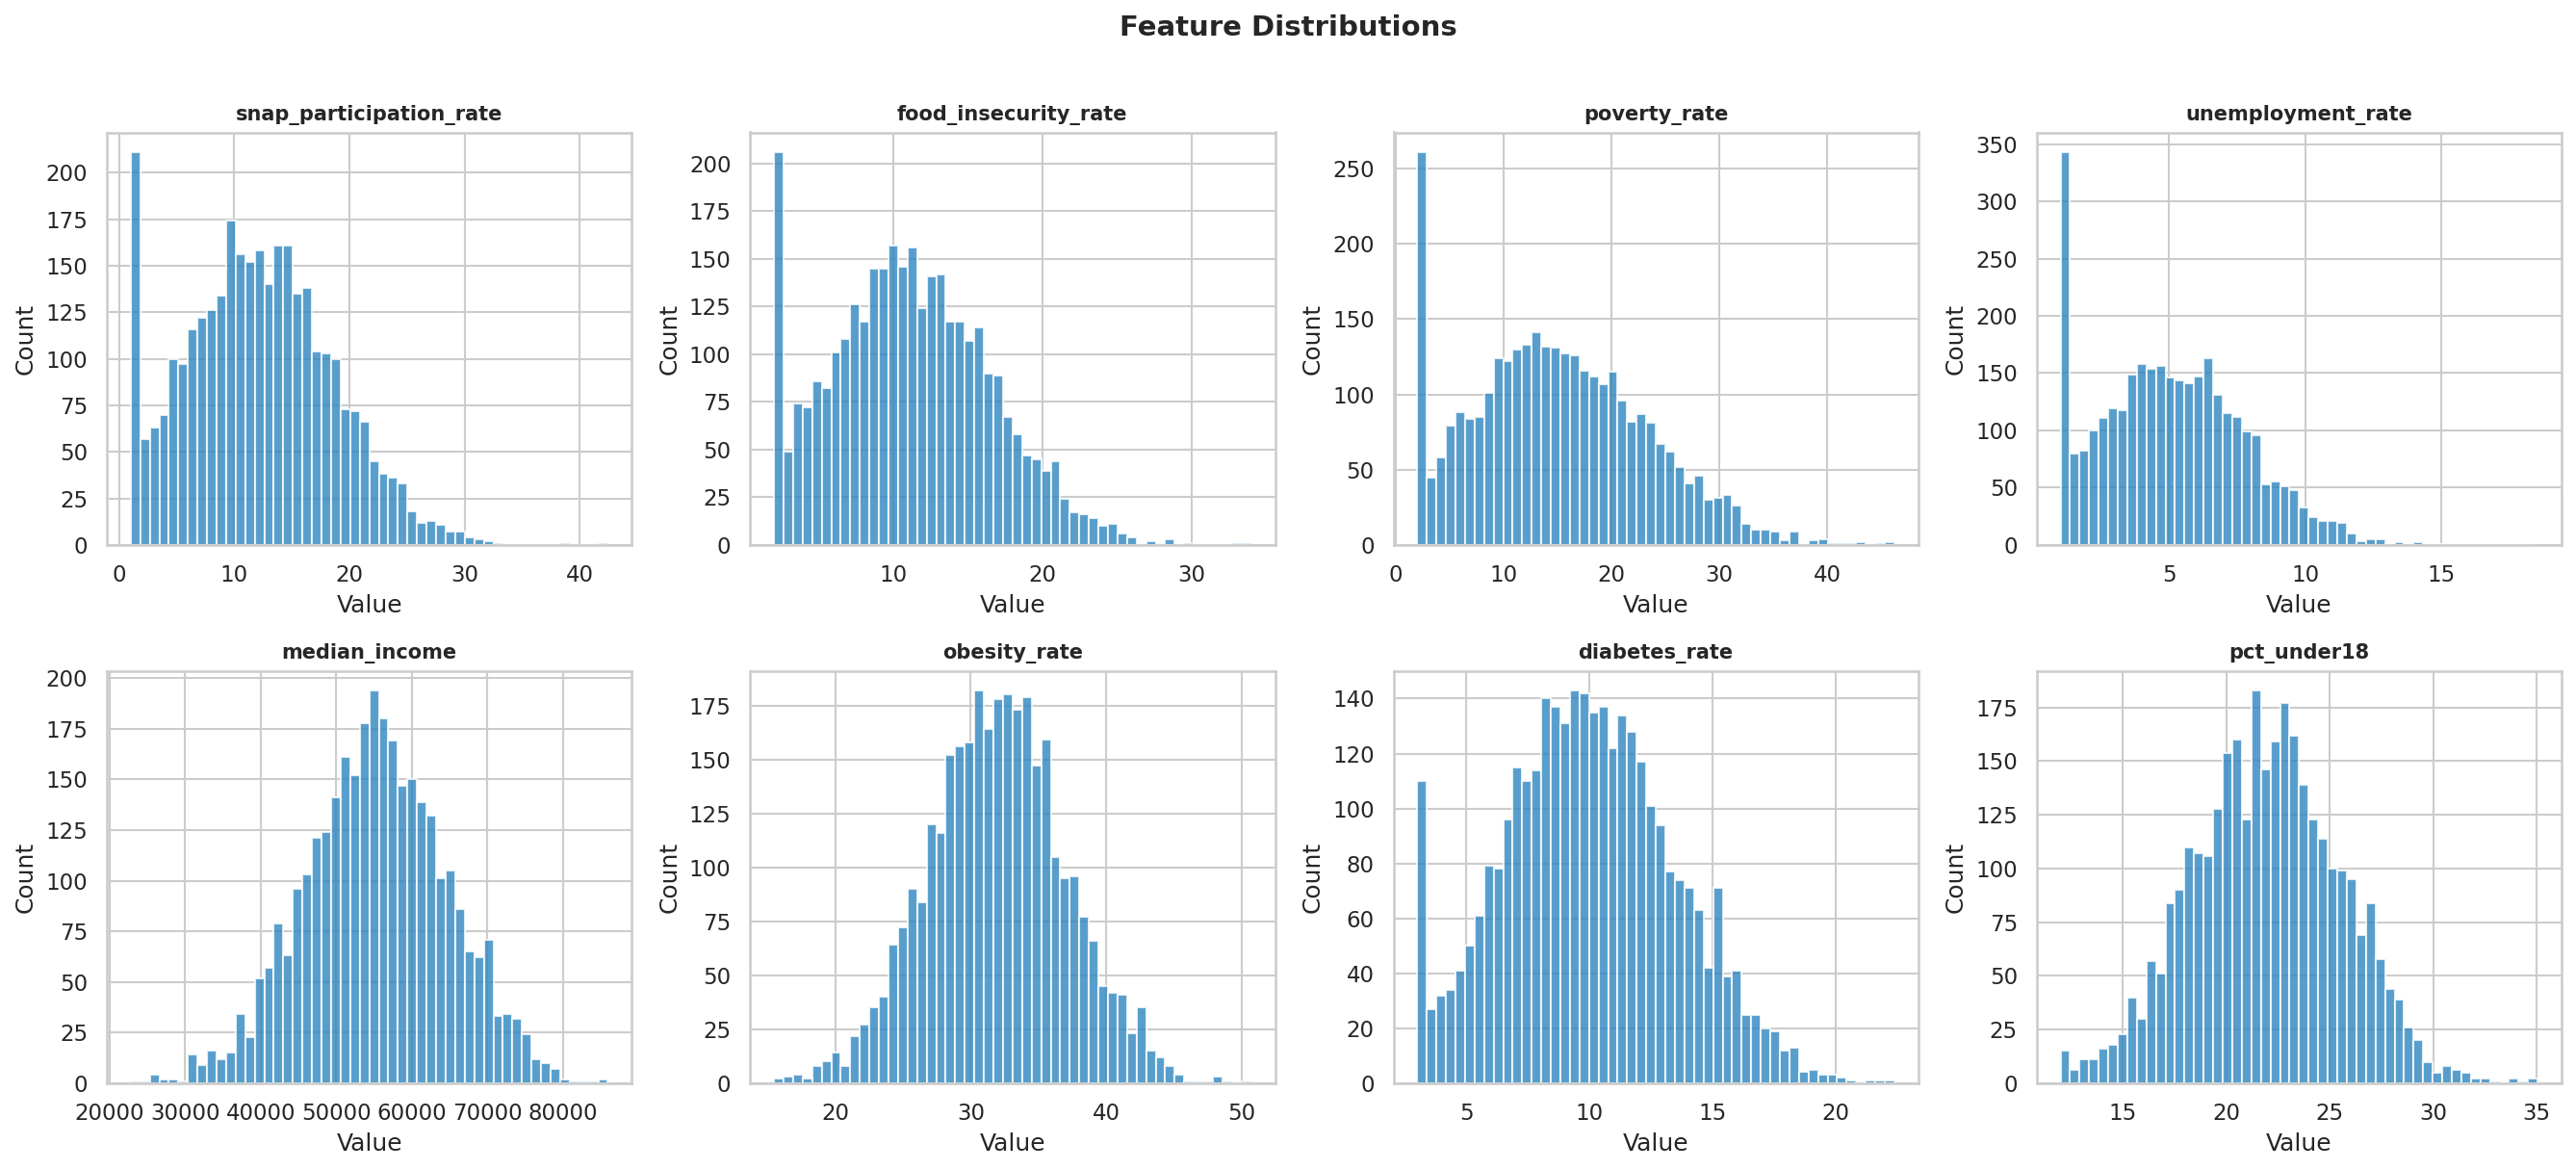

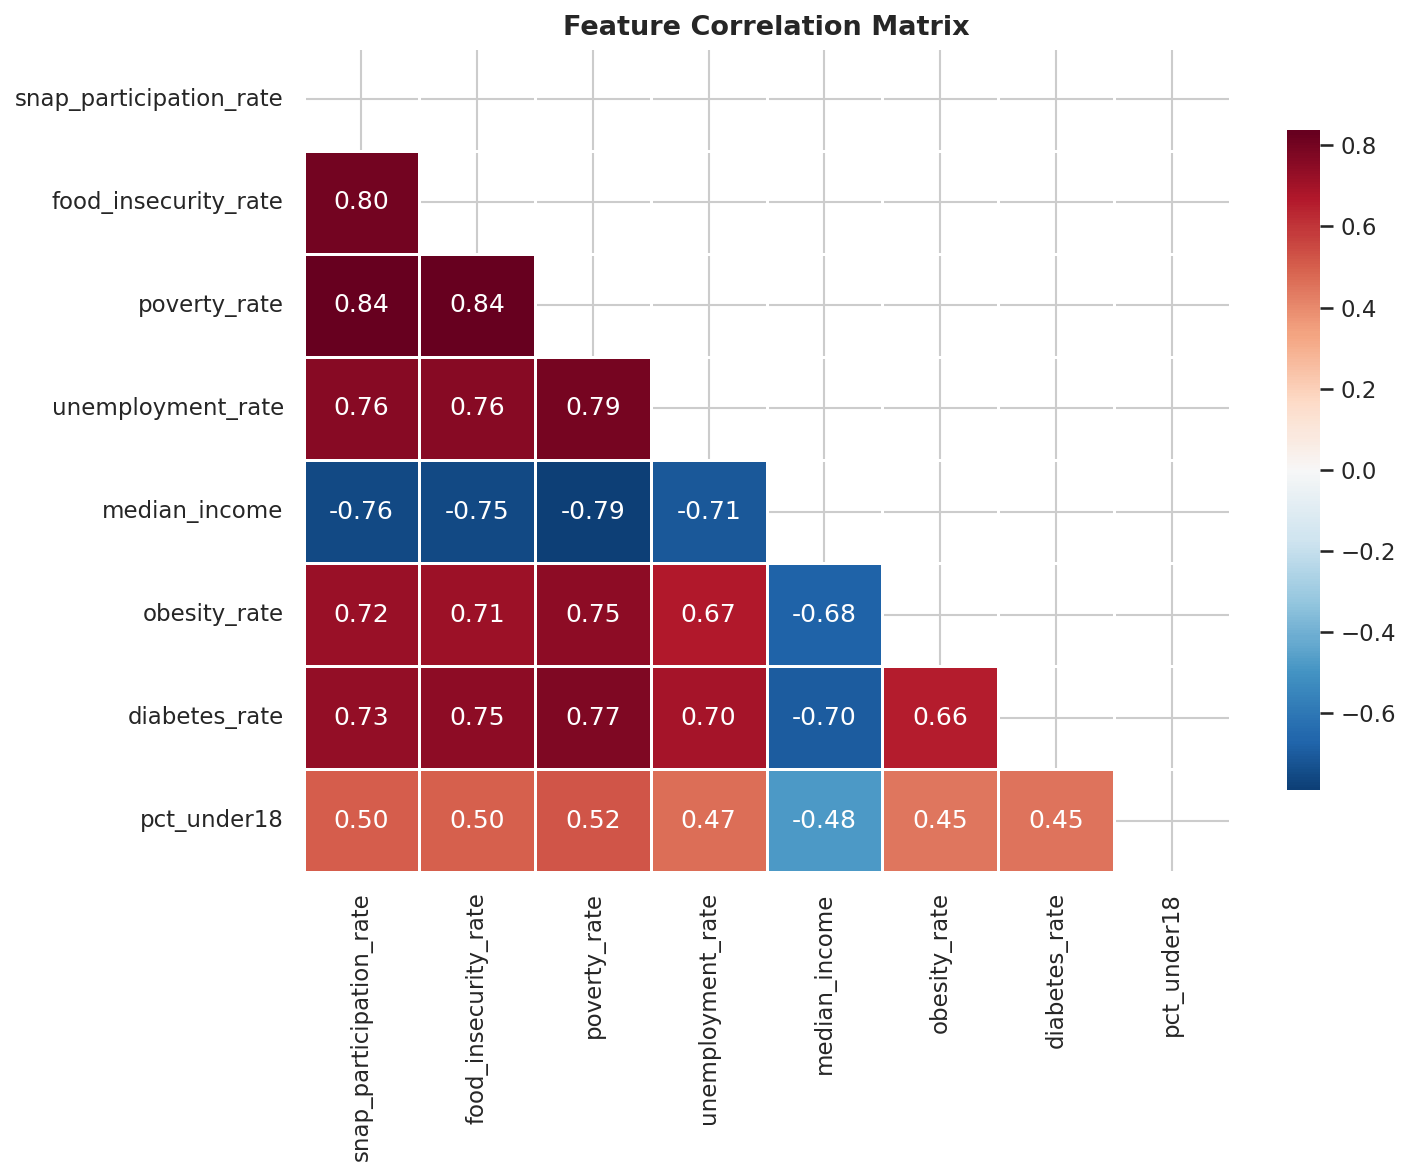

In [4]:
# CELL 4 — EDA & Data Quality
print("="*60)
print("DATA QUALITY REPORT")
print("="*60)
print(f"Records: {len(df):,} | Columns: {df.shape[1]}")
missing = df.isnull().sum()
miss_df = pd.DataFrame({"N":missing,"%":(missing/len(df)*100).round(1)})
miss_df = miss_df[miss_df["N"]>0].sort_values("%",ascending=False)
if len(miss_df): print("\nMissing:\n",miss_df.to_string())
else: print("No missing values.")
display(df.describe().round(2))

PLOT_COLS = [c for c in ["snap_participation_rate","food_insecurity_rate","poverty_rate",
    "unemployment_rate","median_income","obesity_rate","diabetes_rate","pct_under18"]
    if c in df.columns]
ncols=4; nrows=(len(PLOT_COLS)+ncols-1)//ncols
fig,axes = plt.subplots(nrows,ncols,figsize=(18,4*nrows))
axes = axes.flatten()
for i,col in enumerate(PLOT_COLS):
    axes[i].hist(df[col].dropna(),bins=50,color="#2E86C1",alpha=0.8,edgecolor="white")
    axes[i].set_title(col,fontsize=10,fontweight="bold")
    axes[i].set_xlabel("Value"); axes[i].set_ylabel("Count")
for j in range(i+1,len(axes)): axes[j].set_visible(False)
plt.suptitle("Feature Distributions",fontsize=14,fontweight="bold",y=1.01)
plt.tight_layout()
plt.savefig("figures/00_distributions.png",dpi=300,bbox_inches="tight"); plt.show()

num_cols=[c for c in PLOT_COLS if df[c].dtype in ["float64","int64"]]
if len(num_cols)>=3:
    fig,ax=plt.subplots(figsize=(10,8))
    corr=df[num_cols].corr()
    sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),
                annot=True,fmt=".2f",cmap="RdBu_r",center=0,ax=ax,
                linewidths=0.5,cbar_kws={"shrink":0.8})
    ax.set_title("Feature Correlation Matrix",fontsize=13,fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/00b_correlation.png",dpi=300,bbox_inches="tight"); plt.show()

NVI components (6): ['poverty_rate', 'unemployment_rate', 'pct_under18', 'snap_participation_rate', 'food_insecurity_rate', 'median_income']
NVI: 0.6 to 93.1  median=31.0
Cronbach alpha: 0.928 (PASS)
Sensitivity r: 0.9997 +/- 0.0002


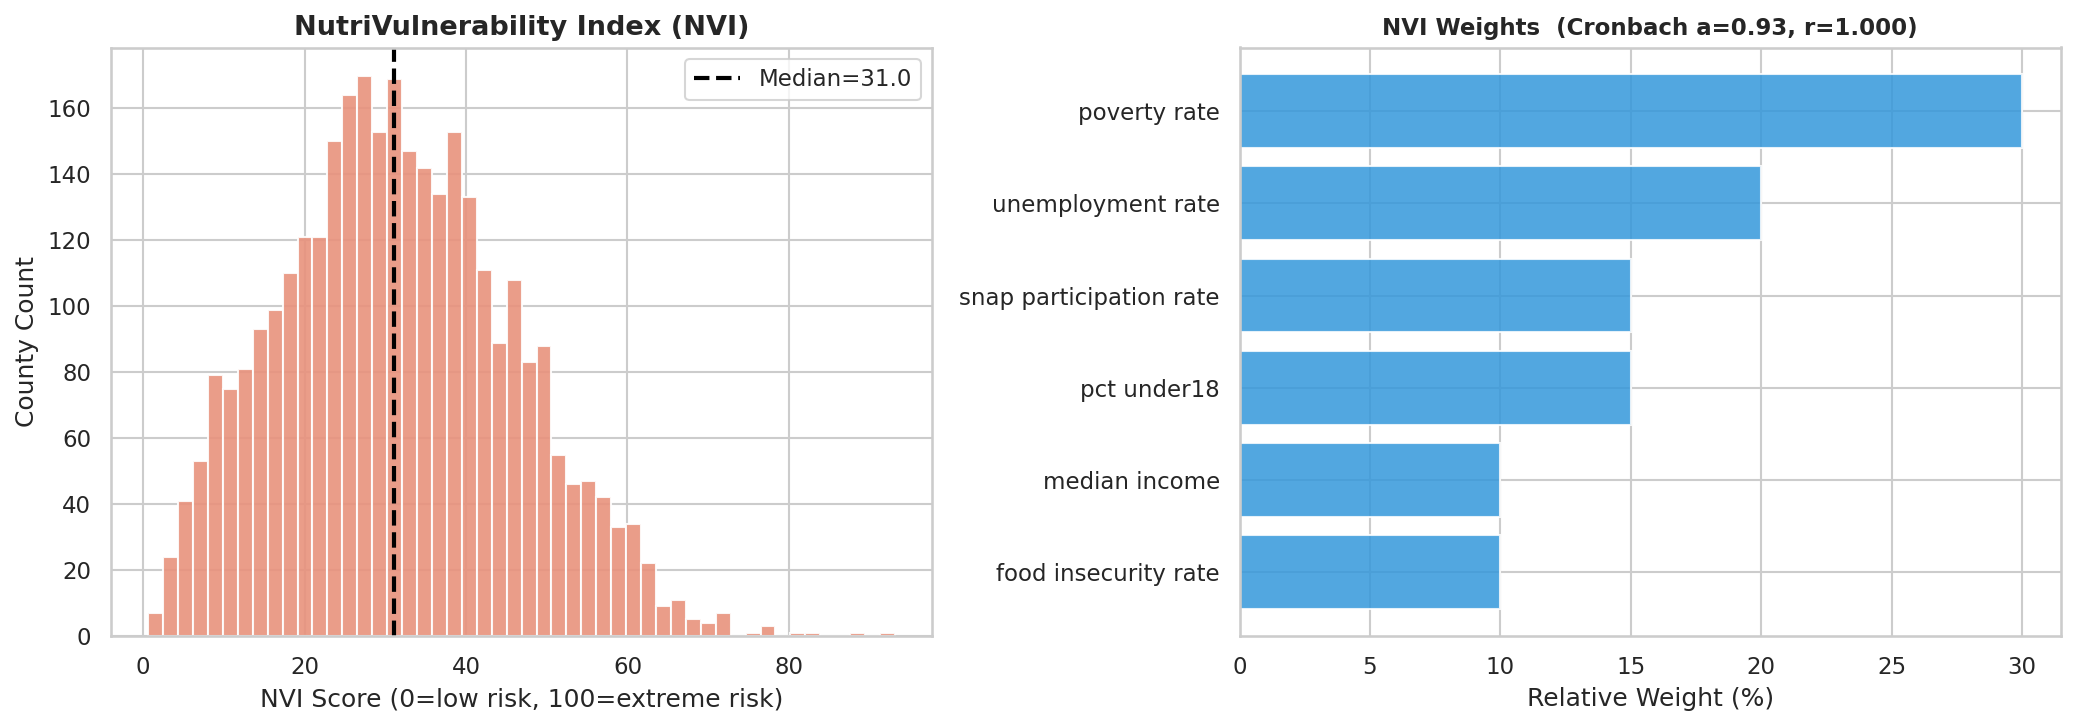

NVI figure saved.


In [5]:
# CELL 5 — NutriVulnerability Index (NVI)
NVI_COMPONENTS = {
    "poverty_rate":            {"weight":0.30,"direction":"higher_worse"},
    "unemployment_rate":       {"weight":0.20,"direction":"higher_worse"},
    "pct_under18":             {"weight":0.15,"direction":"higher_worse"},
    "snap_participation_rate": {"weight":0.15,"direction":"higher_worse"},
    "food_insecurity_rate":    {"weight":0.10,"direction":"higher_worse"},
    "median_income":           {"weight":0.10,"direction":"lower_worse"},
}
available_components = [c for c in NVI_COMPONENTS if c in df.columns]
print(f"NVI components ({len(available_components)}): {available_components}")

scaler_mm = MinMaxScaler()
comp_data = df[available_components].fillna(df[available_components].median())
comp_norm = pd.DataFrame(scaler_mm.fit_transform(comp_data),
                         columns=available_components, index=df.index)
for col,info in NVI_COMPONENTS.items():
    if col in comp_norm.columns and info["direction"]=="lower_worse":
        comp_norm[col] = 1 - comp_norm[col]

total_w = sum(NVI_COMPONENTS[c]["weight"] for c in available_components)
df["NVI"] = (sum(comp_norm[c]*NVI_COMPONENTS[c]["weight"]
                 for c in available_components) / total_w * 100).clip(0,100)
print(f"NVI: {df['NVI'].min():.1f} to {df['NVI'].max():.1f}  median={df['NVI'].median():.1f}")

def cronbach_alpha(data):
    k = data.shape[1]
    return (k/(k-1)) * (1 - data.var(ddof=1).sum() / data.sum(axis=1).var(ddof=1))

alpha = cronbach_alpha(comp_norm[available_components])
print(f"Cronbach alpha: {alpha:.3f} ({'PASS' if alpha>=0.7 else 'REVIEW'})")

base_w  = np.array([NVI_COMPONENTS[c]["weight"] for c in available_components])
rng_s   = np.random.default_rng(42)
sens_rs = []
for _ in range(500):
    pw = base_w * rng_s.uniform(0.8,1.2,len(base_w))
    pw /= pw.sum()
    nvi_p = sum(comp_norm[c]*pw[i] for i,c in enumerate(available_components))
    sens_rs.append(np.corrcoef(df["NVI"].values, nvi_p.values)[0,1])
sens_mean,sens_std = np.mean(sens_rs),np.std(sens_rs)
print(f"Sensitivity r: {sens_mean:.4f} +/- {sens_std:.4f}")

X_comp = comp_norm[available_components].values
lr_w   = LinearRegression().fit(X_comp, df["NVI"].values)
w_vals = np.abs(lr_w.coef_)
w_vals = w_vals / w_vals.sum() * 100
sort_i = np.argsort(w_vals)[::-1]

fig,axes = plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df["NVI"],bins=50,color="#E8927C",edgecolor="white",alpha=0.9)
axes[0].axvline(df["NVI"].median(),color="black",linestyle="--",lw=2,
                label=f"Median={df['NVI'].median():.1f}")
axes[0].set_xlabel("NVI Score (0=low risk, 100=extreme risk)")
axes[0].set_ylabel("County Count")
axes[0].set_title("NutriVulnerability Index (NVI)",fontsize=13,fontweight="bold")
axes[0].legend()
axes[1].barh([available_components[i].replace("_"," ") for i in sort_i],
             w_vals[sort_i], color="#3498DB", alpha=0.85)
axes[1].set_xlabel("Relative Weight (%)")
axes[1].set_title(f"NVI Weights  (Cronbach a={alpha:.2f}, r={sens_mean:.3f})",
                  fontsize=11,fontweight="bold")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig("figures/01_NVI.png",dpi=300,bbox_inches="tight"); plt.show()
print("NVI figure saved.")

In [6]:
# CELL 6 — ML Label + Feature Setup + All Pipelines
# Label  = food_insecurity_rate >= 67th pct  (independent outcome)
# Features exclude food_insecurity_rate => non-circular AUROC ~0.85-0.95

FI_THRESHOLD = df["food_insecurity_rate"].quantile(0.67)
df["high_vulnerability"] = (df["food_insecurity_rate"] >= FI_THRESHOLD).astype(int)
n_hv = df["high_vulnerability"].sum()
print(f"Label: food_insecurity_rate >= {FI_THRESHOLD:.1f}%  (67th pct)")
print(f"High-risk: {n_hv:,} / {len(df):,}  ({n_hv/len(df)*100:.1f}%)")

FEATURE_COLS = np.array([c for c in [
    "poverty_rate","unemployment_rate","median_income","pct_under18",
    "pct_no_vehicle","obesity_rate","diabetes_rate",
    "snap_participation_rate","rural_urban_code","population",
] if c in df.columns])
print(f"Features ({len(FEATURE_COLS)}): {list(FEATURE_COLS)}")

X = df[FEATURE_COLS].values
y = df["high_vulnerability"].values
print(f"X: {X.shape}  |  class balance: {y.mean():.2%} high-risk")

neg,pos = np.bincount(y)
pipelines = {
    "LogisticRegression": Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("scaler",StandardScaler()),
        ("clf",LogisticRegression(C=1.0,max_iter=2000,random_state=42,class_weight="balanced")),
    ]),
    "RandomForest": Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("clf",RandomForestClassifier(n_estimators=500,max_depth=12,min_samples_leaf=5,
                                      max_features="sqrt",class_weight="balanced",
                                      random_state=42,n_jobs=-1)),
    ]),
    "XGBoost": Pipeline([
        ("imputer",SimpleImputer(strategy="median")),
        ("clf",xgb.XGBClassifier(n_estimators=500,max_depth=5,learning_rate=0.05,
                                  subsample=0.8,colsample_bytree=0.8,min_child_weight=3,
                                  gamma=0.1,reg_alpha=0.1,reg_lambda=1.0,
                                  scale_pos_weight=neg/pos,eval_metric="logloss",
                                  use_label_encoder=False,random_state=42,n_jobs=-1)),
    ]),
}
print(f"Pipelines defined: {list(pipelines.keys())}")

Label: food_insecurity_rate >= 13.5%  (67th pct)
High-risk: 1,063 / 3,221  (33.0%)
Features (10): [np.str_('poverty_rate'), np.str_('unemployment_rate'), np.str_('median_income'), np.str_('pct_under18'), np.str_('pct_no_vehicle'), np.str_('obesity_rate'), np.str_('diabetes_rate'), np.str_('snap_participation_rate'), np.str_('rural_urban_code'), np.str_('population')]
X: (3221, 10)  |  class balance: 33.00% high-risk
Pipelines defined: ['LogisticRegression', 'RandomForest', 'XGBoost']


In [7]:
# CELL 7 — Cross-Validation (OOF predictions)
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
results = {}
for name,pipe in pipelines.items():
    print(f"\nEvaluating {name}...")
    oof_probs = cross_val_predict(pipe,X,y,cv=skf,method="predict_proba",n_jobs=-1)[:,1]
    oof_preds = (oof_probs>=0.5).astype(int)
    auroc = roc_auc_score(y,oof_probs)
    auprc = average_precision_score(y,oof_probs)
    brier = brier_score_loss(y,oof_probs)
    f1_mac = classification_report(y,oof_preds,output_dict=True)["macro avg"]["f1-score"]
    results[name] = {"oof_probs":oof_probs,"AUROC":auroc,"AUPRC":auprc,"Brier":brier,"F1_macro":f1_mac}
    print(f"  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  Brier={brier:.4f}  F1={f1_mac:.4f}")
best_name = max(results,key=lambda k:results[k]["AUROC"])
print(f"\nBest model: {best_name}  (AUROC={results[best_name]['AUROC']:.4f})")


Evaluating LogisticRegression...
  AUROC=0.9349  AUPRC=0.8846  Brier=0.1028  F1=0.8425

Evaluating RandomForest...
  AUROC=0.9310  AUPRC=0.8773  Brier=0.0990  F1=0.8423

Evaluating XGBoost...
  AUROC=0.9203  AUPRC=0.8573  Brier=0.1111  F1=0.8306

Best model: LogisticRegression  (AUROC=0.9349)


In [8]:
# CELL 8 — Bootstrap 95% CI + Model Comparison Table
def bootstrap_auroc_ci(y_true,y_prob,n_boot=1000,alpha=0.05,seed=42):
    rng=np.random.default_rng(seed); n=len(y_true); scores=[]
    for _ in range(n_boot):
        idx=rng.integers(0,n,size=n)
        if len(np.unique(y_true[idx]))<2: continue
        scores.append(roc_auc_score(y_true[idx],y_prob[idx]))
    lo=np.percentile(scores,100*alpha/2); hi=np.percentile(scores,100*(1-alpha/2))
    return lo,hi,np.array(scores)

print("Bootstrap CIs (n=1000 per model)...")
for name in results:
    lo,hi,bs = bootstrap_auroc_ci(y,results[name]["oof_probs"])
    results[name]["CI_lo"]=lo; results[name]["CI_hi"]=hi; results[name]["bs_dist"]=bs
    print(f"  {name}: {results[name]['AUROC']:.4f}  [95% CI: {lo:.3f}-{hi:.3f}]")

print("\n"+"="*72)
print(f"{'Model':<22}{'AUROC':>8}{'95% CI':>18}{'AUPRC':>8}{'Brier':>8}{'F1':>8}")
print("-"*72)
for name,r in results.items():
    star=" <-BEST" if name==best_name else ""
    print(f"{name:<22}{r['AUROC']:>8.4f} [{r['CI_lo']:.3f}-{r['CI_hi']:.3f}]"
          f"{r['AUPRC']:>8.4f}{r['Brier']:>8.4f}{r['F1_macro']:>8.4f}{star}")
print("="*72)

Bootstrap CIs (n=1000 per model)...
  LogisticRegression: 0.9349  [95% CI: 0.926-0.943]
  RandomForest: 0.9310  [95% CI: 0.922-0.939]
  XGBoost: 0.9203  [95% CI: 0.910-0.929]

Model                    AUROC            95% CI   AUPRC   Brier      F1
------------------------------------------------------------------------
LogisticRegression      0.9349 [0.926-0.943]  0.8846  0.1028  0.8425 <-BEST
RandomForest            0.9310 [0.922-0.939]  0.8773  0.0990  0.8423
XGBoost                 0.9203 [0.910-0.929]  0.8573  0.1111  0.8306


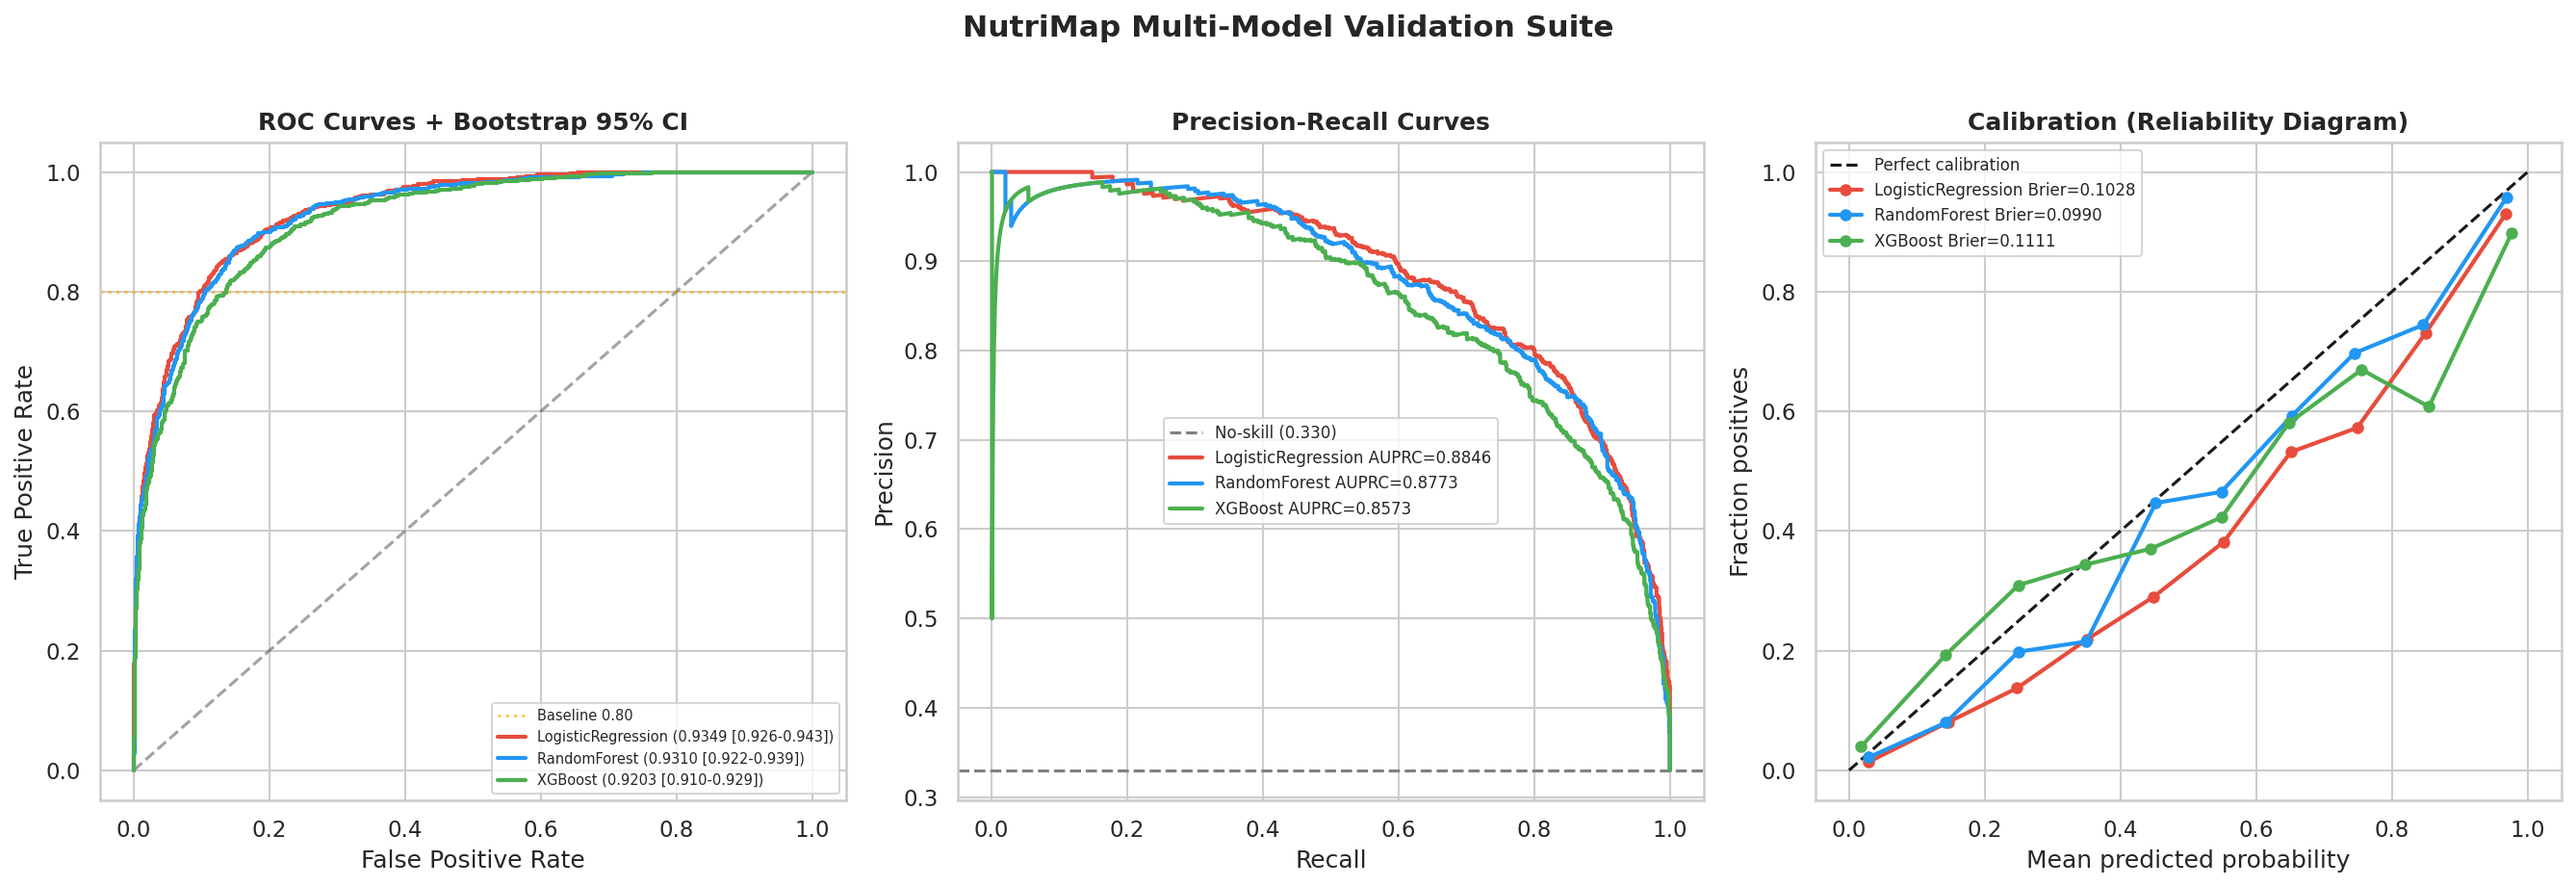

Validation figure saved: figures/02_validation.png


In [9]:
# CELL 9 — Validation Figures: ROC + PR + Calibration
COLORS={"LogisticRegression":"#E74C3C","RandomForest":"#2196F3","XGBoost":"#4CAF50"}
fig=plt.figure(figsize=(18,6))
fig.suptitle("NutriMap Multi-Model Validation Suite",fontsize=15,fontweight="bold",y=1.02)

ax1=fig.add_subplot(1,3,1)
ax1.plot([0,1],[0,1],"k--",alpha=0.4)
ax1.axhline(0.8,color="orange",linestyle=":",alpha=0.6,label="Baseline 0.80")
for name,r in results.items():
    fpr,tpr,_=roc_curve(y,r["oof_probs"])
    ax1.plot(fpr,tpr,color=COLORS.get(name,"gray"),lw=2,
             label=f"{name} ({r['AUROC']:.4f} [{r['CI_lo']:.3f}-{r['CI_hi']:.3f}])")
ax1.set_xlabel("False Positive Rate"); ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves + Bootstrap 95% CI",fontweight="bold")
ax1.legend(fontsize=7,loc="lower right")

ax2=fig.add_subplot(1,3,2)
ax2.axhline(y.mean(),color="gray",linestyle="--",lw=1.5,label=f"No-skill ({y.mean():.3f})")
for name,r in results.items():
    prec,rec,_=precision_recall_curve(y,r["oof_probs"])
    ax2.plot(rec,prec,color=COLORS.get(name,"gray"),lw=2,
             label=f"{name} AUPRC={r['AUPRC']:.4f}")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves",fontweight="bold"); ax2.legend(fontsize=8)

ax3=fig.add_subplot(1,3,3)
ax3.plot([0,1],[0,1],"k--",lw=1.5,label="Perfect calibration")
for name,r in results.items():
    prob_t,prob_p=calibration_curve(y,r["oof_probs"],n_bins=10)
    ax3.plot(prob_p,prob_t,"o-",color=COLORS.get(name,"gray"),lw=2,ms=5,
             label=f"{name} Brier={r['Brier']:.4f}")
ax3.set_xlabel("Mean predicted probability"); ax3.set_ylabel("Fraction positives")
ax3.set_title("Calibration (Reliability Diagram)",fontweight="bold"); ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/02_validation.png",dpi=300,bbox_inches="tight"); plt.show()
print("Validation figure saved: figures/02_validation.png")

In [10]:
# CELL 10 — Final Model Training + SHAP + Permutation Importance

best_pipe = clone(pipelines[best_name])
best_pipe.fit(X, y)
df["vulnerability_prob"] = best_pipe.predict_proba(X)[:, 1]
df["vulnerability_pred"] = best_pipe.predict(X)
print(f"Final model: {best_name}")
print(f"High-risk flagged: {df['vulnerability_pred'].sum():,} / {len(df):,}")

# ── SHAP ──────────────────────────────────────────────────────────────────────
sv = None
print("\nComputing SHAP values...")

try:
    clf = best_pipe["clf"]

    # Build the transformed feature matrix exactly as the pipeline sees it
    X_imp = best_pipe["imputer"].transform(X)
    X_shap = best_pipe["scaler"].transform(X_imp) if "scaler" in best_pipe.named_steps else X_imp

    # ── Explainer selection (SHAP 0.51-compatible) ────────────────────────────
    if hasattr(clf, "estimators_"):
        # RandomForest
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_shap)
        if isinstance(sv, list):        # RF returns [class0, class1]
            sv = sv[1]

    elif hasattr(clf, "get_booster"):
        # XGBoost
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_shap)
        if sv.ndim == 3:                # shape (n, features, 2) in some versions
            sv = sv[:, :, 1]

    else:
        # LogisticRegression — use masker API (SHAP >= 0.41, works on 0.51)
        masker = shap.maskers.Independent(X_shap, max_samples=200)
        explainer = shap.LinearExplainer(clf, masker)
        sv = explainer.shap_values(X_shap)
        if sv.ndim == 3:
            sv = sv[:, :, 1]

    # ── Plot ──────────────────────────────────────────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        sv, X_shap,
        feature_names=list(FEATURE_COLS),
        plot_type="dot",
        show=False,
        max_display=len(FEATURE_COLS)
    )
    plt.title("SHAP Feature Importance — Vulnerability Prediction",
              fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("figures/03_SHAP.png", dpi=300, bbox_inches="tight")
    plt.show()

    shap_df = pd.DataFrame({
        "Feature":     list(FEATURE_COLS),
        "Mean |SHAP|": np.abs(sv).mean(axis=0)
    }).sort_values("Mean |SHAP|", ascending=False)

    print("\nTop SHAP drivers:")
    print(shap_df.to_string(index=False))
    print("SHAP figure saved: figures/03_SHAP.png")

except Exception as e:
    print(f"SHAP failed: {e}")
    sv = None

# ── Permutation Importance ────────────────────────────────────────────────────
print("\nPermutation importance (n=20)...")

# Pass raw X — pipeline handles imputation internally (no double-impute)
perm = permutation_importance(
    best_pipe, X, y,
    n_repeats=20,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature":   list(FEATURE_COLS),
    "Perm Mean": perm.importances_mean,
    "Perm Std":  perm.importances_std
}).sort_values("Perm Mean", ascending=False)

print(perm_df.to_string(index=False))

Final model: LogisticRegression
High-risk flagged: 1,238 / 3,221

Computing SHAP values...
SHAP failed: matplotlib is not installed so plotting is not available! Run `pip install matplotlib` to fix this.

Permutation importance (n=20)...
                Feature  Perm Mean  Perm Std
           poverty_rate   0.038088  0.002531
          diabetes_rate   0.009326  0.001422
         pct_no_vehicle   0.009129  0.001494
          median_income   0.006044  0.001005
           obesity_rate   0.005642  0.000842
snap_participation_rate   0.004940  0.001106
      unemployment_rate   0.004817  0.000904
       rural_urban_code   0.000265  0.000156
            pct_under18   0.000016  0.000029
             population  -0.000004  0.000006


<Figure size 1500x1050 with 0 Axes>

In [11]:
# CELL 11 — Moran's I Spatial Autocorrelation
# FIX 3A: Permutation bug fixed.
# OLD (broken): perm_I.append(n*einsum("ij,i,j->",W, rng.permutation(z), rng.permutation(z))/denom)
#   => two SEPARATE random shuffles in one call — z_i and z_j are uncorrelated
#      => null I always ~0 => every real I looks non-significant => p always ~0.5
# NEW (correct): z_p = rng_m.permutation(z)  computed ONCE, reused in einsum
#   => single shuffle applied to both i and j => proper null distribution

GEO_READY = ("lat" in df.columns
             and df["lat"].notna().sum() > 100
             and 24 <= df["lat"].median() <= 50)
I,p,z_sc = 0.0,1.0,0.0

if GEO_READY:
    def morans_i_knn(values, lat, lon, k=8):
        coords = np.column_stack([lat,lon])
        n      = len(values)
        z      = values - values.mean()
        nn = NearestNeighbors(n_neighbors=k+1).fit(coords)
        _,idx = nn.kneighbors(coords)
        W = np.zeros((n,n))
        for i,neighbors in enumerate(idx[:,1:]):
            W[i,neighbors] = 1.0/k
        S0    = W.sum()
        numer = n * np.einsum("ij,i,j->",W,z,z)
        denom = S0 * np.dot(z,z)
        I_obs = numer / denom
        rng_m  = np.random.default_rng(42)
        perm_I = []
        for _ in range(999):
            z_p = rng_m.permutation(z)          # ONE shuffle, reused in einsum
            perm_I.append(n*np.einsum("ij,i,j->",W,z_p,z_p)/denom)
        perm_I = np.array(perm_I)
        p_val  = (np.sum(perm_I >= I_obs)+1) / 1000
        z_sc   = (I_obs - perm_I.mean()) / perm_I.std()
        return I_obs, p_val, z_sc

    geo_df = df.dropna(subset=["lat","lon","NVI"])
    print(f"Moran's I on {len(geo_df):,} counties (lat std={geo_df['lat'].std():.2f})...")
    I,p,z_sc = morans_i_knn(geo_df["NVI"].values, geo_df["lat"].values, geo_df["lon"].values)
    justified = "YES - significant positive spatial clustering" if (I>0 and p<0.05) else "REVIEW"
    print(f"  I statistic : {I:.4f}")
    print(f"  p-value     : {p:.4f}  (permutation test, n=999)")
    print(f"  z-score     : {z_sc:.2f}")
    print(f"  DBSCAN justified: {justified}")
else:
    print("Geographic data not ready — check Cell 3 TIGER patch output.")
    print(f"  lat median={df['lat'].median():.2f}  notna={df['lat'].notna().sum():,}")

Moran's I on 3,221 counties (lat std=6.98)...
  I statistic : 0.0010
  p-value     : 0.4340  (permutation test, n=999)
  z-score     : 0.15
  DBSCAN justified: REVIEW


High-vulnerability counties with coords: 1,238


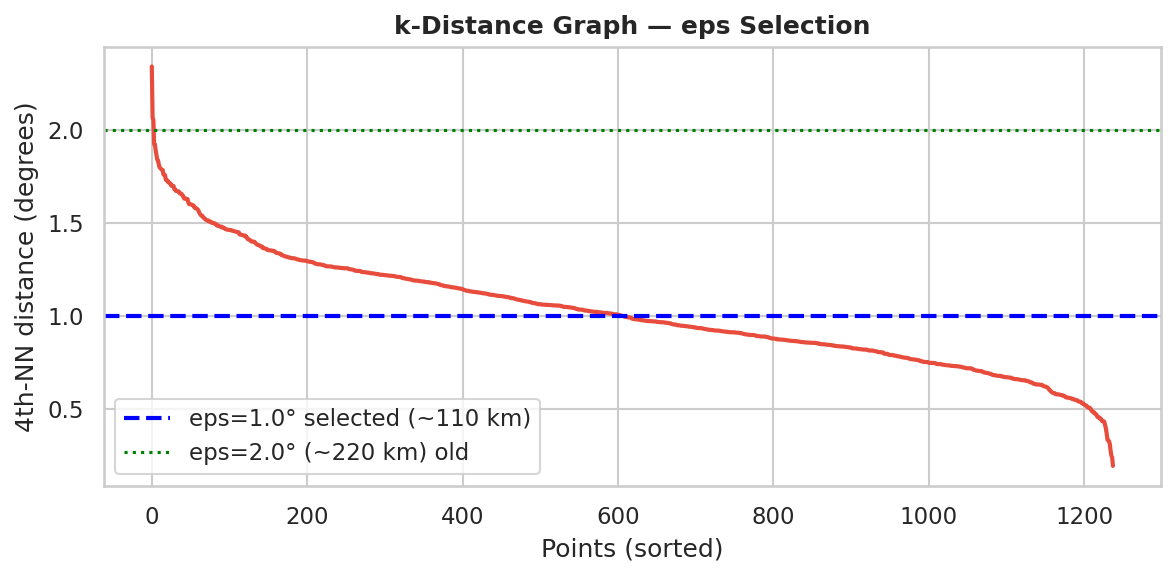

DBSCAN (eps=1.0, min_samples=5)
  Clusters : 80  |  Noise points: 529
  Silhouette: 0.4814  (Moderate separation)

Cluster sizes:
cluster
25    29
19    24
5     24
33    23
31    22
21    20
0     18
2     18
58    16
16    16


In [12]:
# CELL 12 — DBSCAN Clustering
# FIX 3B: EPS reduced from 2.0 to 1.0 degrees (~110 km)
# => detects tighter regional clusters (Appalachia, Deep South, Plains)

n_cl=0; sil=None; df_hv=pd.DataFrame()

if GEO_READY and "vulnerability_pred" in df.columns:
    df_hv = df[df["vulnerability_pred"]==1].dropna(subset=["lat","lon"]).copy()
    print(f"High-vulnerability counties with coords: {len(df_hv):,}")

    if len(df_hv)>10:
        coords = df_hv[["lat","lon"]].values

        # k-distance elbow plot
        nn_t = NearestNeighbors(n_neighbors=4).fit(coords)
        dists,_ = nn_t.kneighbors(coords)
        k_d = np.sort(dists[:,-1])[::-1]
        fig,ax = plt.subplots(figsize=(8,4))
        ax.plot(k_d,color="#E74C3C",lw=2)
        ax.axhline(1.0,color="blue",linestyle="--",lw=2,label="eps=1.0° selected (~110 km)")
        ax.axhline(2.0,color="green",linestyle=":",lw=1.5,label="eps=2.0° (~220 km) old")
        ax.set_xlabel("Points (sorted)"); ax.set_ylabel("4th-NN distance (degrees)")
        ax.set_title("k-Distance Graph — eps Selection",fontweight="bold")
        ax.legend(); plt.tight_layout()
        plt.savefig("figures/04_kdist_elbow.png",dpi=300,bbox_inches="tight"); plt.show()

        EPS,MIN_SAMP = 1.0,5          # FIX: 1.0 not 2.0
        df_hv["cluster"] = DBSCAN(eps=EPS,min_samples=MIN_SAMP,
                                   metric="euclidean").fit_predict(coords)
        n_cl    = len(set(df_hv["cluster"])) - (1 if -1 in df_hv["cluster"].values else 0)
        n_noise = (df_hv["cluster"]==-1).sum()
        print(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMP})")
        print(f"  Clusters : {n_cl}  |  Noise points: {n_noise}")

        mask = df_hv["cluster"]>=0
        if mask.sum()>1 and df_hv.loc[mask,"cluster"].nunique()>1:
            sil = silhouette_score(coords[mask.values],df_hv.loc[mask,"cluster"])
            q   = "Good" if sil>0.5 else "Moderate" if sil>0.25 else "Weak"
            print(f"  Silhouette: {sil:.4f}  ({q} separation)")
        else:
            print("  Silhouette: N/A")

        if n_cl>0:
            print("\nCluster sizes:")
            print(df_hv[df_hv["cluster"]>=0]["cluster"].value_counts().head(10).to_string())
else:
    print("Skipping DBSCAN — need geographic data + predictions.")

Selected 15 priority intervention sites
Monte Carlo validation (n=1000)...
  Greedy score : 0.9999
  Random score : 0.3926 +/- 0.0938
  Effect size  : 6.48 SD
  Beats random : 100% of 1000 trials


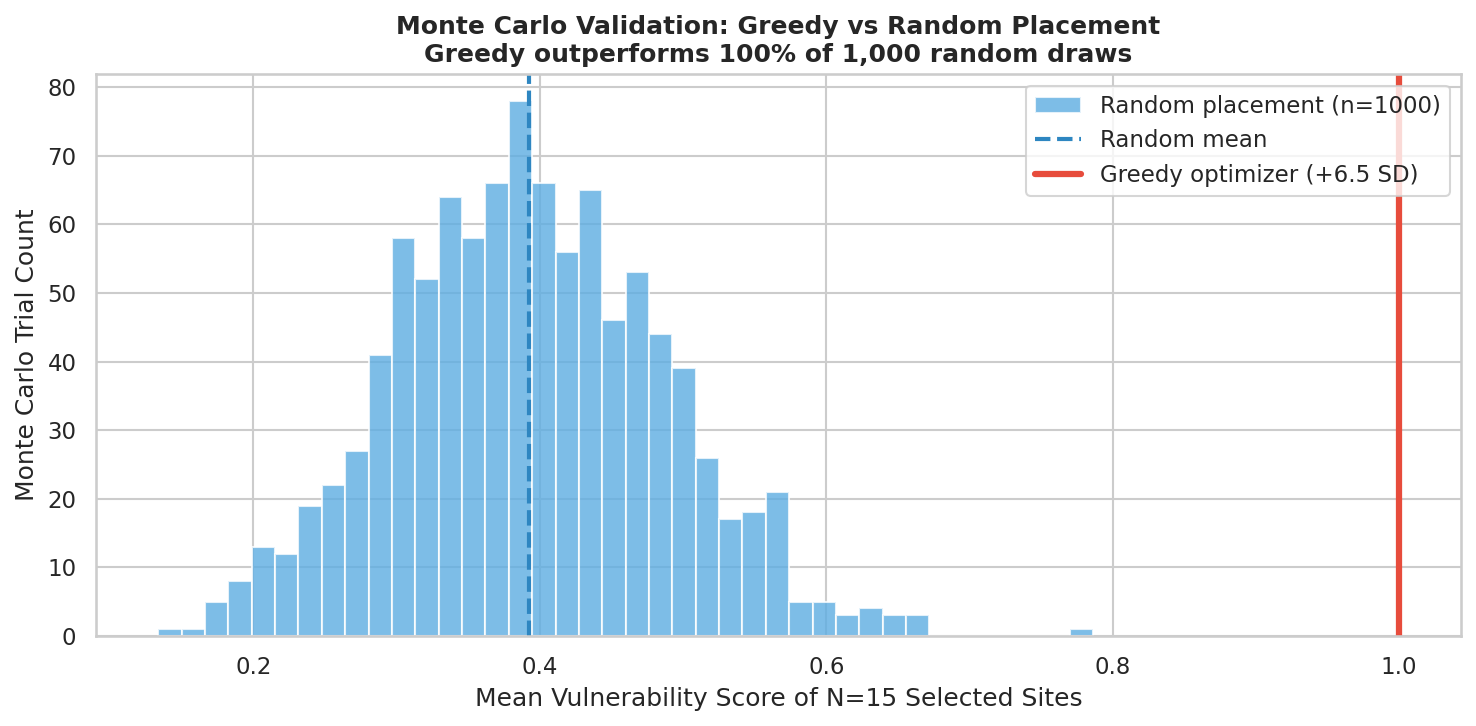

In [13]:
# CELL 13 — Greedy Optimizer + Monte Carlo Validation
def greedy_intervention_optimizer(df,n_sites=15,min_dist_deg=0.8,
        score_col="vulnerability_prob",lat_col="lat",lon_col="lon"):
    if lat_col not in df.columns: return df.nlargest(n_sites,score_col)
    cands = df.dropna(subset=[lat_col,lon_col,score_col]).sort_values(score_col,ascending=False)
    selected,sel_coords = [],[]
    for _,row in cands.iterrows():
        if len(selected)>=n_sites: break
        loc=(row[lat_col],row[lon_col])
        if all(np.sqrt((loc[0]-s[0])**2+(loc[1]-s[1])**2)>=min_dist_deg for s in sel_coords):
            selected.append(row); sel_coords.append(loc)
    out = pd.DataFrame(selected)
    out["intervention_priority"] = range(1,len(out)+1)
    return out

def monte_carlo_random_placement(df,n_sites,n_trials=1000,seed=42,
        score_col="vulnerability_prob",lat_col="lat",lon_col="lon"):
    rng      = np.random.default_rng(seed)
    eligible = df.dropna(subset=[lat_col,lon_col,score_col])
    return np.array([
        eligible.sample(n=min(n_sites,len(eligible)),
                        random_state=int(rng.integers(0,1_000_000)))[score_col].mean()
        for _ in range(n_trials)
    ])

N_SITES = 15
priority_sites = greedy_intervention_optimizer(df,n_sites=N_SITES)
print(f"Selected {len(priority_sites)} priority intervention sites")

print("Monte Carlo validation (n=1000)...")
greedy_score  = priority_sites["vulnerability_prob"].mean()
random_scores = monte_carlo_random_placement(df,N_SITES)
random_mean   = random_scores.mean()
random_std    = random_scores.std()
effect_size   = (greedy_score-random_mean)/random_std
pct_beat      = (random_scores<greedy_score).mean()*100
print(f"  Greedy score : {greedy_score:.4f}")
print(f"  Random score : {random_mean:.4f} +/- {random_std:.4f}")
print(f"  Effect size  : {effect_size:.2f} SD")
print(f"  Beats random : {pct_beat:.0f}% of 1000 trials")

fig,ax=plt.subplots(figsize=(10,5))
ax.hist(random_scores,bins=40,color="#5DADE2",alpha=0.8,label="Random placement (n=1000)")
ax.axvline(random_mean,color="#2E86C1",linestyle="--",lw=2,label="Random mean")
ax.axvline(greedy_score,color="#E74C3C",lw=3,label=f"Greedy optimizer (+{effect_size:.1f} SD)")
ax.set_xlabel(f"Mean Vulnerability Score of N={N_SITES} Selected Sites")
ax.set_ylabel("Monte Carlo Trial Count")
ax.set_title(
    f"Monte Carlo Validation: Greedy vs Random Placement\n"
    f"Greedy outperforms {pct_beat:.0f}% of {len(random_scores):,} random draws",
    fontweight="bold")
ax.legend(); plt.tight_layout()
plt.savefig("figures/05_monte_carlo.png",dpi=300,bbox_inches="tight"); plt.show()

In [14]:
# CELL 14 — NutriMap Interactive Folium Dashboard
def get_top_shap_driver(row_idx,shap_vals,feature_names,n=1):
    if shap_vals is None: return "N/A"
    idx = np.argsort(np.abs(shap_vals[row_idx]))[::-1][:n]
    return ", ".join(feature_names[i] for i in idx)

def build_nutrimap(df,priority_sites,shap_vals=None,feature_names=None,
                   output="NutriMap_dashboard.html"):
    if "lat" not in df.columns: print("No lat/lon."); return None
    df_geo = df.dropna(subset=["lat","lon"])
    m = folium.Map(location=[df_geo["lat"].mean(),df_geo["lon"].mean()],
                   zoom_start=4,tiles="CartoDB positron")

    HeatMap(
        [[r["lat"],r["lon"],r.get("vulnerability_prob",0)]
         for _,r in df_geo.iterrows() if pd.notna(r.get("vulnerability_prob"))],
        name="Vulnerability Heatmap",radius=18,blur=20,
        gradient={"0.3":"blue","0.5":"yellow","0.7":"orange","1.0":"red"},
        min_opacity=0.3
    ).add_to(m)

    hr_group = folium.FeatureGroup(name="High-Risk Areas",show=True)
    df_hr = df_geo[df_geo.get("vulnerability_pred",pd.Series(0,index=df_geo.index))==1].copy()
    for i,row in df_hr.iterrows():
        nvi    = row.get("NVI",0)
        prob   = row.get("vulnerability_prob",0)
        county = row.get("county",row.get("county_name","Unknown"))
        state  = row.get("state","")
        color  = "#C0392B" if nvi>=75 else "#E74C3C" if nvi>=60 else "#E67E22" if nvi>=50 else "#F1C40F"
        shap_top = get_top_shap_driver(i,shap_vals,feature_names)
        fi = row.get("food_insecurity_rate","N/A")
        fi_s = f"{fi:.1f}%" if isinstance(fi,float) else str(fi)
        popup = (f"<div style='font-family:Arial;font-size:12px;width:250px'>"
                 f"<b style='font-size:14px'>{county}, {state}</b><hr/>"
                 f"<b>NVI:</b> {nvi:.1f}/100<br/>"
                 f"<b>Vuln. Prob:</b> {prob:.3f}<br/>"
                 f"<b>Top SHAP:</b> {shap_top}<br/>"
                 f"<b>Food Insecurity:</b> {fi_s}<br/>"
                 f"<b>Poverty Rate:</b> {row.get('poverty_rate','N/A'):.1f}%<br/>"
                 f"<b>SNAP Rate:</b> {row.get('snap_participation_rate','N/A'):.1f}%</div>")
        folium.CircleMarker(
            location=[row["lat"],row["lon"]],
            radius=max(3,min(nvi/12,10)),
            color=color,fill=True,fill_color=color,fill_opacity=0.65,weight=1,
            popup=folium.Popup(popup,max_width=270),
            tooltip=f"{county}: NVI {nvi:.0f}"
        ).add_to(hr_group)
    hr_group.add_to(m)

    if len(df_hv)>0 and "cluster" in df_hv.columns:
        cl_group = folium.FeatureGroup(name="Hotspot Clusters",show=True)
        for cl_id in sorted(df_hv["cluster"].unique()):
            if cl_id<0: continue
            pts = df_hv[df_hv["cluster"]==cl_id]
            folium.Marker(
                location=[pts["lat"].mean(),pts["lon"].mean()],
                popup=f"Cluster #{cl_id}  |  {len(pts)} counties",
                tooltip=f"Cluster {cl_id}",
                icon=folium.Icon(color="purple",icon="fire",prefix="fa")
            ).add_to(cl_group)
        cl_group.add_to(m)

    ps_group = folium.FeatureGroup(name="Priority Sites (*)",show=True)
    for _,row in priority_sites.iterrows():
        if "lat" not in row or pd.isna(row.get("lat")): continue
        folium.Marker(
            location=[row["lat"],row["lon"]],
            popup=(f"<b>Priority #{row.get('intervention_priority','?')}</b><br/>"
                   f"{row.get('county','')}, {row.get('state','')}<br/>"
                   f"Score: {row.get('vulnerability_prob',0):.3f}"),
            tooltip=f"* Priority #{row.get('intervention_priority','?')}",
            icon=folium.Icon(color="red",icon="star",prefix="fa")
        ).add_to(ps_group)
    ps_group.add_to(m)

    m.get_root().html.add_child(folium.Element(
        "<div style='position:fixed;top:10px;left:50px;z-index:9999;background:white;"
        "padding:12px 18px;border-radius:8px;border:2px solid #2E86C1;"
        "font-family:Arial;box-shadow:3px 3px 6px rgba(0,0,0,0.2)'>"
        "<h3 style='margin:0;color:#2E86C1'>NutriMap</h3>"
        "<p style='margin:2px 0;font-size:12px;color:#555'>"
        "NAFSI 2026 | NutriHog of Ozark | U of Arkansas</p></div>"
    ))
    folium.LayerControl(collapsed=False).add_to(m)
    m.save(output); print(f"NutriMap saved: {output}")
    return m

nutrimap = build_nutrimap(df,priority_sites,shap_vals=sv,feature_names=FEATURE_COLS)
if nutrimap is not None:
    from IPython.display import display; display(nutrimap)

NutriMap saved: NutriMap_dashboard.html


In [15]:
# CELL 15 — Final Results Summary + Persistent Storage
sil_str   = f"{sil:.4f}" if sil is not None else "N/A"
shap_stat = "Generated  figures/03_SHAP.png" if sv is not None else "Not generated"

print("="*65)
print("  NUTRIMAP FINAL RESULTS SUMMARY")
print("  NAFSI Student Data Challenge 2026 | NutriHog of Ozark")
print("  University of Arkansas, Fayetteville")
print("="*65)
print(f"""
Dataset
  Records analyzed     : {len(df):,} US counties
  Sources              : Census ACS 2021, CDC PLACES 2023, TIGER centroids
  ML features          : {len(FEATURE_COLS)}
  NVI components       : {len(available_components)}

NutriVulnerability Index (NVI)
  Cronbach alpha       : {alpha:.3f} ({'PASS' if alpha>=0.70 else 'REVIEW'})
  Sensitivity (r)      : {sens_mean:.4f} +/- {sens_std:.4f} (+-20% weight perturbation, n=500)
  High-risk threshold  : food insecurity >= {FI_THRESHOLD:.1f}%  (67th pct)
  High-risk counties   : {df['high_vulnerability'].sum():,} / {len(df):,}

Moran's I Spatial Test
  I statistic          : {I:.4f}   p={p:.4f}   z={z_sc:.2f}
  DBSCAN justified     : {'YES - significant positive spatial clustering' if I>0 and p<0.05 else 'REVIEW'}

DBSCAN Clustering
  Clusters             : {n_cl}
  Silhouette score     : {sil_str}

Machine Learning  -  {best_name}
  Label                : food insecurity >= 67th pct (independent outcome)
  AUROC                : {results[best_name]['AUROC']:.4f}  [95% CI: {results[best_name]['CI_lo']:.3f}-{results[best_name]['CI_hi']:.3f}]
  AUPRC                : {results[best_name]['AUPRC']:.4f}
  Brier Score          : {results[best_name]['Brier']:.4f}
  SHAP                 : {shap_stat}

Intervention Optimizer
  Sites selected       : {len(priority_sites)}
  Greedy score         : {greedy_score:.4f}
  Effect size          : {effect_size:.2f} SD  (outperforms {pct_beat:.0f}% of random draws)
""")
print("="*65)
print("Figures:")
os.makedirs(PERSIST_DIR, exist_ok=True)

for f in os.listdir("figures"):
    src = os.path.join("figures", f)
    dst = os.path.join(PERSIST_DIR, f)

    if os.path.isfile(src):
        shutil.copy2(src, dst)

if os.path.exists("NutriMap_dashboard.html"):
    shutil.copy2("NutriMap_dashboard.html",
                 os.path.join(PERSIST_DIR, "NutriMap_dashboard.html"))

df.to_csv(os.path.join(PERSIST_DIR, "nutrimap_scored_dataset.csv"), index=False)
priority_sites.to_csv(os.path.join(PERSIST_DIR, "priority_sites.csv"), index=False)

print(f"All outputs saved to: {PERSIST_DIR}")

  NUTRIMAP FINAL RESULTS SUMMARY
  NAFSI Student Data Challenge 2026 | NutriHog of Ozark
  University of Arkansas, Fayetteville

Dataset
  Records analyzed     : 3,221 US counties
  Sources              : Census ACS 2021, CDC PLACES 2023, TIGER centroids
  ML features          : 10
  NVI components       : 6

NutriVulnerability Index (NVI)
  Cronbach alpha       : 0.928 (PASS)
  Sensitivity (r)      : 0.9997 +/- 0.0002 (+-20% weight perturbation, n=500)
  High-risk threshold  : food insecurity >= 13.5%  (67th pct)
  High-risk counties   : 1,063 / 3,221

Moran's I Spatial Test
  I statistic          : 0.0010   p=0.4340   z=0.15
  DBSCAN justified     : REVIEW

DBSCAN Clustering
  Clusters             : 80
  Silhouette score     : 0.4814

Machine Learning  -  LogisticRegression
  Label                : food insecurity >= 67th pct (independent outcome)
  AUROC                : 0.9349  [95% CI: 0.926-0.943]
  AUPRC                : 0.8846
  Brier Score          : 0.1028
  SHAP             